In [1]:
import duckdb
import pandas as pd

data_path = '../data/processed/ecommerce_clean.parquet'

In [2]:
query = f"""
SELECT
    COUNT(*) AS pv,
    COUNT(DISTINCT user_id) AS uv,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS buyers,
    SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchases,
    SUM(CASE WHEN event_type = 'purchase' AND price > 0 THEN price ELSE 0 END) AS gmv
FROM '{data_path}'
"""

core_metrics = duckdb.sql(query).df()
core_metrics

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,pv,uv,buyers,purchases,gmv
0,109819992,5316649,697470,1659703.0,5.051263e+08


计算转化率和客单价

购买用户转化率：购买用户数 ÷ 总用户数 × 100%
平均每次购买金额：GMV ÷ purchase 行为数

In [3]:
metrics = core_metrics.copy()

metrics["purchase_conversion_rate"] = (
    metrics["buyers"] / metrics["uv"] * 100
)

metrics["avg_order_value"] = (
    metrics["gmv"] / metrics["purchases"]
)

metrics

,pv,uv,buyers,purchases,gmv,purchase_conversion_rate,avg_order_value
0,109819992,5316649,697470,1659703.0,5.051263e+08,13.118602,304.3474


In [4]:
query = f"""
SELECT
    CAST(event_time AS DATE) AS date,
    COUNT(*) AS pv,
    COUNT(DISTINCT user_id) AS uv,
    SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchases
FROM '{data_path}'
GROUP BY date
ORDER BY date
"""

daily_metrics = duckdb.sql(query).df()
daily_metrics.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,pv,uv,purchases
0,2019-10-01,1243715,190188,19305.0
1,2019-10-02,1190853,184965,19469.0
2,2019-10-03,1126624,170668,19255.0
3,2019-10-04,1415939,209410,27039.0
4,2019-10-05,1329334,194958,23492.0


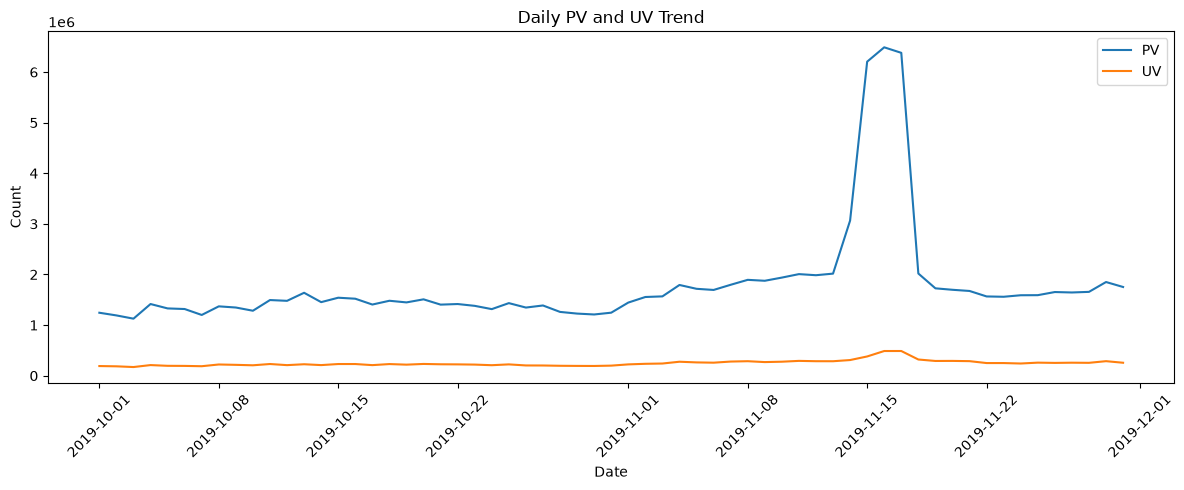

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(daily_metrics["date"], daily_metrics["pv"], label="PV")
plt.plot(daily_metrics["date"], daily_metrics["uv"], label="UV")

plt.title("Daily PV and UV Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

每日购买趋势

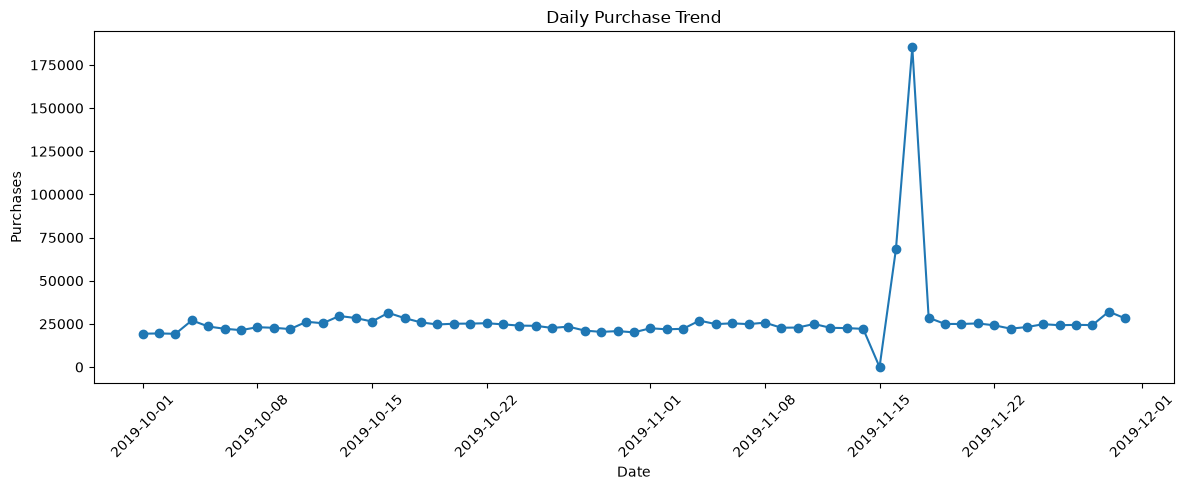

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_metrics["date"],
    daily_metrics["purchases"],
    marker="o"
)

plt.title("Daily Purchase Trend")
plt.xlabel("Date")
plt.ylabel("Purchases")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

每天有多少用户实际购买，以及每日购买转化率是多少

In [7]:
query = f"""
SELECT
    CAST(event_time AS DATE) AS date,
    COUNT(DISTINCT user_id) AS uv,
    COUNT(DISTINCT CASE
        WHEN event_type = 'purchase' THEN user_id
    END) AS buyers
FROM '{data_path}'
GROUP BY date
ORDER BY date
"""

daily_conversion = duckdb.sql(query).df()

daily_conversion["conversion_rate"] = (
    daily_conversion["buyers"] /
    daily_conversion["uv"] * 100
)

daily_conversion.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,date,uv,buyers,conversion_rate
0,2019-10-01,190188,14064,7.394788
1,2019-10-02,184965,13894,7.511691
2,2019-10-03,170668,13722,8.040172
3,2019-10-04,209410,19214,9.175302
4,2019-10-05,194958,16734,8.583387


当天购买用户数 ÷ 当天活跃用户数 × 100%

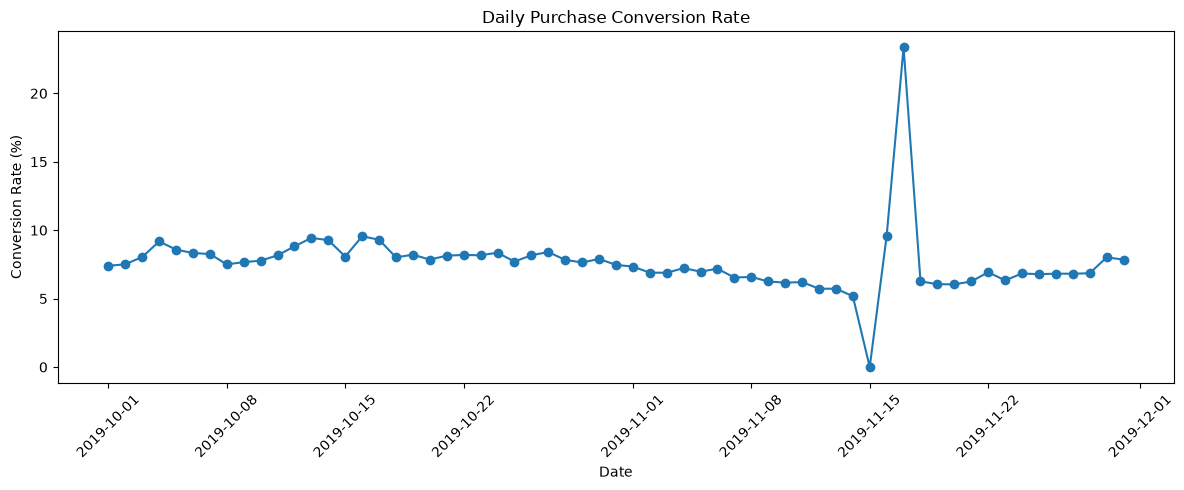

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_conversion["date"],
    daily_conversion["conversion_rate"],
    marker="o"
)

plt.title("Daily Purchase Conversion Rate")
plt.xlabel("Date")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

用户行为漏斗

浏览（view） → 加购（cart） → 购买（purchase）

In [9]:
query = f"""
SELECT
    event_type,
    COUNT(DISTINCT user_id) AS user_count
FROM '{data_path}'
GROUP BY event_type
ORDER BY
    CASE event_type
        WHEN 'view' THEN 1
        WHEN 'cart' THEN 2
        WHEN 'purchase' THEN 3
    END
"""

funnel = duckdb.sql(query).df()
funnel

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,user_count
0,view,5316128
1,cart,1054127
2,purchase,697470


检查用户行为路径

In [10]:
query = f"""
WITH user_behavior AS (
    SELECT
        user_id,
        MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase
    FROM '{data_path}'
    GROUP BY user_id
)

SELECT
    has_view,
    has_cart,
    has_purchase,
    COUNT(*) AS user_count
FROM user_behavior
GROUP BY has_view, has_cart, has_purchase
ORDER BY user_count DESC
"""

behavior_path = duckdb.sql(query).df()
behavior_path

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,has_view,has_cart,has_purchase,user_count
0,1,0,0,4130964
1,1,1,1,565775
2,1,1,0,487980
3,1,0,1,131409
4,0,1,0,235
5,0,0,1,149
6,0,1,1,137


In [11]:
view_users = funnel.loc[funnel["event_type"] == "view", "user_count"].iloc[0]
cart_users = funnel.loc[funnel["event_type"] == "cart", "user_count"].iloc[0]
purchase_users = funnel.loc[funnel["event_type"] == "purchase", "user_count"].iloc[0]

cart_rate = cart_users / view_users * 100
purchase_rate = purchase_users / view_users * 100

print(f"浏览用户数：{view_users:,}")
print(f"加购用户数：{cart_users:,}")
print(f"购买用户数：{purchase_users:,}")
print(f"浏览用户中发生加购的比例：{cart_rate:.2f}%")
print(f"浏览用户中发生购买的比例：{purchase_rate:.2f}%")

浏览用户数：5,316,128
加购用户数：1,054,127
购买用户数：697,470
浏览用户中发生加购的比例：19.83%
浏览用户中发生购买的比例：13.12%


画用户行为漏斗图

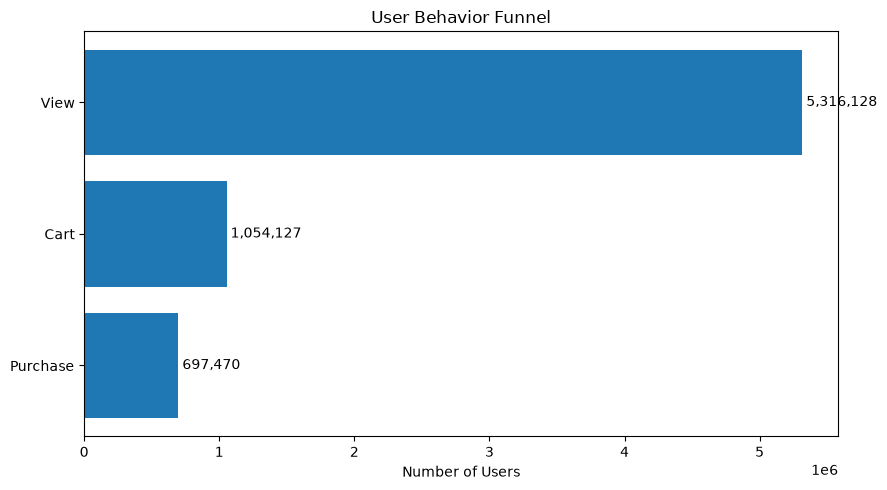

In [12]:
stages = ["View", "Cart", "Purchase"]
users = [view_users, cart_users, purchase_users]

plt.figure(figsize=(9, 5))

bars = plt.barh(stages, users)

plt.title("User Behavior Funnel")
plt.xlabel("Number of Users")

for bar, value in zip(bars, users):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:,}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 品类销售分析

通过购买行为分析不同商品品类的销售表现，识别购买量较高的主要品类。

In [13]:
query = f"""
SELECT
    category_code,
    COUNT(*) AS purchases,
    ROUND(SUM(price), 2) AS gmv,
    COUNT(DISTINCT user_id) AS buyers
FROM '{data_path}'
WHERE event_type = 'purchase'
    AND category_code IS NOT NULL
    AND price > 0
GROUP BY category_code
ORDER BY purchases DESC
LIMIT 10
"""

top_categories = duckdb.sql(query).df()
top_categories

,category_code,purchases,gmv,buyers
0,electronics.smartphone,720625,3.348553e+08,322110
1,electronics.audio.headphone,71335,9.208310e+06,42128
2,electronics.video.tv,51834,2.087912e+07,32584
3,electronics.clocks,41140,1.136983e+07,24605
4,appliances.kitchen.washer,35917,1.046005e+07,23074
5,computers.notebook,34021,1.965731e+07,20389
6,appliances.environment.vacuum,30571,4.478737e+06,23019
7,appliances.kitchen.refrigerators,24260,8.552734e+06,16948
8,apparel.shoes,14395,1.263447e+06,9188
9,electronics.tablet,11740,3.131170e+06,7640


Top 10 品类购买量

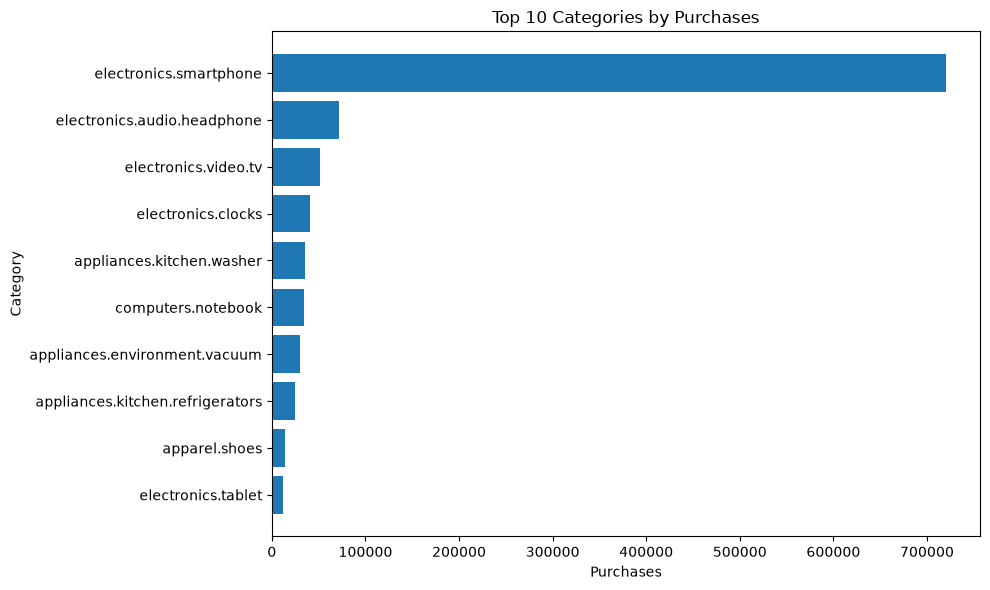

In [14]:
category_plot = top_categories.sort_values("purchases")

plt.figure(figsize=(10, 6))

plt.barh(
    category_plot["category_code"],
    category_plot["purchases"]
)

plt.title("Top 10 Categories by Purchases")
plt.xlabel("Purchases")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

计算主要品类的浏览用户与购买用户

In [15]:
query = f"""
SELECT
    category_code,
    COUNT(DISTINCT CASE
        WHEN event_type = 'view' THEN user_id
    END) AS viewers,
    COUNT(DISTINCT CASE
        WHEN event_type = 'purchase' THEN user_id
    END) AS buyers
FROM '{data_path}'
WHERE category_code IS NOT NULL
GROUP BY category_code
"""

category_conversion = duckdb.sql(query).df()

category_conversion["conversion_rate"] = (
    category_conversion["buyers"]
    / category_conversion["viewers"]
    * 100
)

category_conversion.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category_code,viewers,buyers,conversion_rate
0,electronics.video.tv,390064,32584,8.353501
1,auto.accessories.player,140718,5888,4.184255
2,electronics.audio.subwoofer,87553,4082,4.662319
3,apparel.jeans,53387,256,0.479517
4,computers.peripherals.keyboard,21621,1006,4.652884


In [16]:
major_categories = (
    category_conversion[
        category_conversion["viewers"] >= 100000
    ]
    .sort_values("conversion_rate", ascending=False)
)

major_categories.head(10)

,category_code,viewers,buyers,conversion_rate
32,electronics.smartphone,2438217,322110,13.210883
91,electronics.audio.headphone,475123,42128,8.866757
33,appliances.kitchen.washer,268483,23074,8.594213
57,appliances.environment.vacuum,272799,23019,8.438081
0,electronics.video.tv,390064,32584,8.353501
13,computers.notebook,297313,20389,6.857756
75,appliances.kitchen.refrigerators,264455,16948,6.408652
5,electronics.tablet,130668,7640,5.846879
14,electronics.clocks,440993,24605,5.579454
120,electronics.telephone,113075,5996,5.302675


主要品类转化率最低的 10 个

In [17]:
major_categories.sort_values(
    "conversion_rate",
    ascending=True
).head(10)

,category_code,viewers,buyers,conversion_rate
45,apparel.costume,145585,1075,0.738400
62,furniture.living_room.sofa,106180,1911,1.799774
86,apparel.shoes.keds,192210,3568,1.856303
27,furniture.bedroom.bed,168985,3597,2.128591
85,accessories.bag,102247,2257,2.207400
94,furniture.living_room.cabinet,129347,3154,2.438402
58,apparel.shoes,355640,9188,2.583511
56,computers.desktop,157286,4726,3.004718
1,auto.accessories.player,140718,5888,4.184255
120,electronics.telephone,113075,5996,5.302675


高低转化对比图

In [18]:
high_conversion = major_categories.head(5)

low_conversion = (
    major_categories
    .sort_values("conversion_rate")
    .head(5)
)

conversion_compare = pd.concat([
    high_conversion,
    low_conversion
])

conversion_compare

,category_code,viewers,buyers,conversion_rate
32,electronics.smartphone,2438217,322110,13.210883
91,electronics.audio.headphone,475123,42128,8.866757
33,appliances.kitchen.washer,268483,23074,8.594213
57,appliances.environment.vacuum,272799,23019,8.438081
0,electronics.video.tv,390064,32584,8.353501
45,apparel.costume,145585,1075,0.738400
62,furniture.living_room.sofa,106180,1911,1.799774
86,apparel.shoes.keds,192210,3568,1.856303
27,furniture.bedroom.bed,168985,3597,2.128591
85,accessories.bag,102247,2257,2.207400


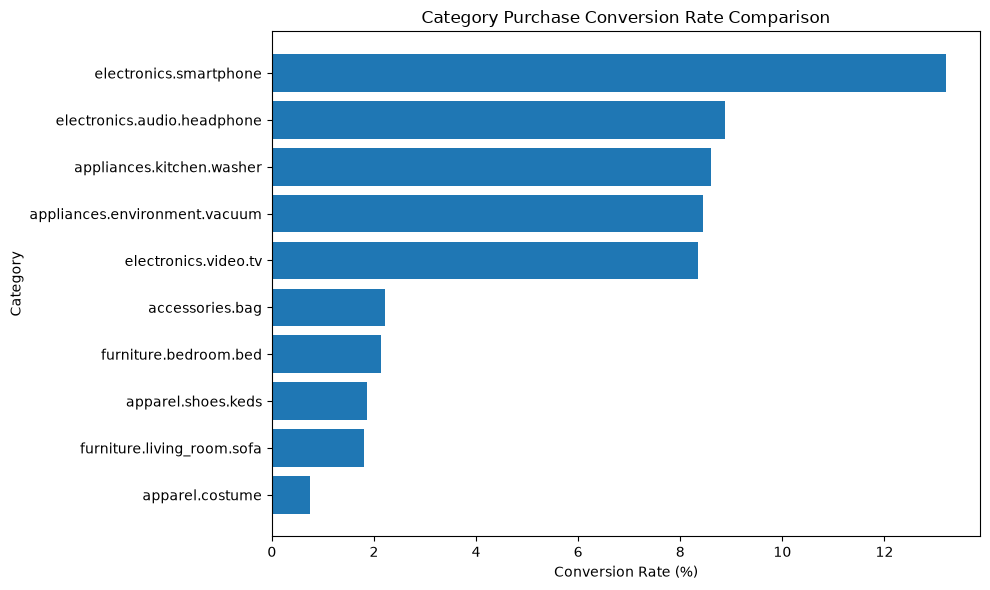

In [19]:
conversion_plot = conversion_compare.sort_values("conversion_rate")

plt.figure(figsize=(10, 6))

plt.barh(
    conversion_plot["category_code"],
    conversion_plot["conversion_rate"]
)

plt.title("Category Purchase Conversion Rate Comparison")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

## 品牌销售分析

从品牌维度分析用户购买行为和销售表现，识别购买量和成交金额较高的主要品牌。

查询 Top 10 品牌

In [20]:
query = f"""
SELECT
    brand,
    COUNT(*) AS purchases,
    COUNT(DISTINCT user_id) AS buyers,
    ROUND(SUM(price), 2) AS gmv
FROM '{data_path}'
WHERE event_type = 'purchase'
    AND brand IS NOT NULL
    AND price > 0
GROUP BY brand
ORDER BY purchases DESC
LIMIT 10
"""

top_brands = duckdb.sql(query).df()
top_brands

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,brand,purchases,buyers,gmv
0,samsung,372904,192790,1.012717e+08
1,apple,308922,134457,2.387120e+08
2,xiaomi,124900,75323,2.045249e+07
3,huawei,47202,30151,9.663787e+06
4,cordiant,27534,19606,1.304972e+06
5,lucente,26133,15341,6.649743e+06
6,oppo,25967,16555,5.900575e+06
7,lg,21604,14902,8.626380e+06
8,sony,17038,11044,6.341083e+06
9,artel,15388,11203,2.675952e+06


In [21]:
top_brands["avg_purchase_value"] = (
    top_brands["gmv"] / top_brands["purchases"]
)

top_brands[
    ["brand", "purchases", "gmv", "avg_purchase_value"]
].sort_values("avg_purchase_value", ascending=False)

,brand,purchases,gmv,avg_purchase_value
1,apple,308922,2.387120e+08,772.725868
7,lg,21604,8.626380e+06,399.295486
8,sony,17038,6.341083e+06,372.172965
0,samsung,372904,1.012717e+08,271.575763
5,lucente,26133,6.649743e+06,254.457689
6,oppo,25967,5.900575e+06,227.233594
3,huawei,47202,9.663787e+06,204.732577
9,artel,15388,2.675952e+06,173.898613
2,xiaomi,124900,2.045249e+07,163.750890
4,cordiant,27534,1.304972e+06,47.394932


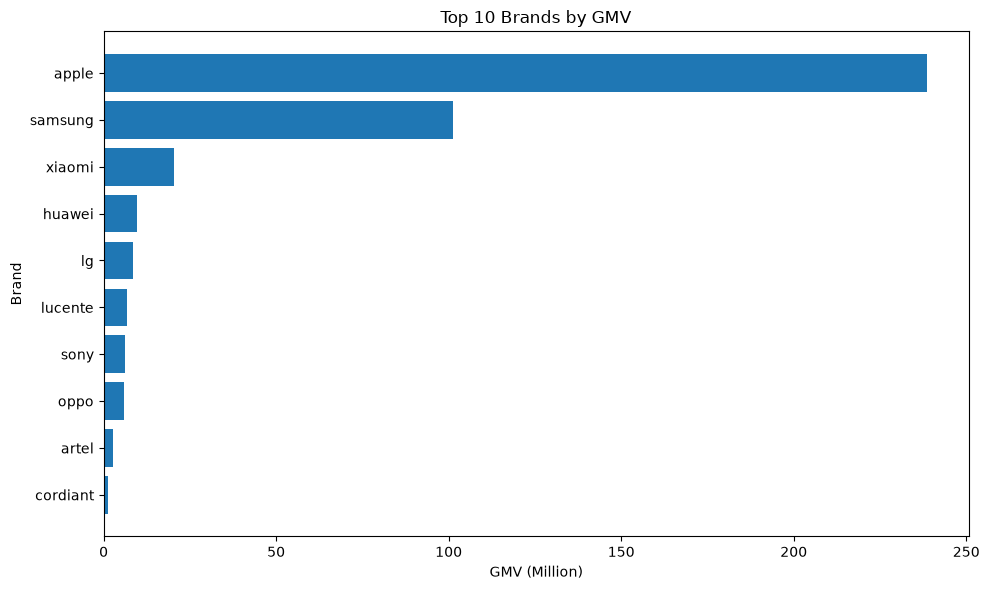

In [22]:
brand_plot = top_brands.sort_values("gmv")

plt.figure(figsize=(10, 6))

plt.barh(
    brand_plot["brand"],
    brand_plot["gmv"] / 1000000
)

plt.title("Top 10 Brands by GMV")
plt.xlabel("GMV (Million)")
plt.ylabel("Brand")
plt.tight_layout()

plt.show()

## 用户价值分析

基于用户购买行为，从最近购买时间、购买频率和消费金额三个维度构建 RFM 指标，用于观察不同用户的消费特征和价值差异。

In [23]:
query = f"""
SELECT
    user_id,
    DATE_DIFF(
        'day',
        MAX(CAST(event_time AS DATE)),
        DATE '2019-12-01'
    ) AS recency,
    COUNT(*) AS frequency,
    ROUND(SUM(price), 2) AS monetary
FROM '{data_path}'
WHERE event_type = 'purchase'
    AND price > 0
GROUP BY user_id
"""

rfm = duckdb.sql(query).df()

rfm.head()

,user_id,recency,frequency,monetary
0,527380590,2,17,11740.51
1,542088934,43,2,129.03
2,512529030,14,28,12072.77
3,513623202,7,3,140.58
4,518632457,1,33,1951.56


RFM 描述性统计

In [24]:
rfm[["recency", "frequency", "monetary"]].describe().round(2)

,recency,frequency,monetary
count,697470.00,697470.00,697470.00
mean,25.55,2.38,724.23
std,17.21,4.41,2271.13
min,1.00,1.00,0.77
25%,13.00,1.00,118.38
50%,21.00,1.00,257.15
75%,40.00,2.00,669.23
max,61.00,640.00,343899.10


RFM 评分

In [25]:
# R：最近购买时间越短，分数越高
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=3,
    labels=[3, 2, 1]
)

# F：购买频率越高，分数越高
rfm["F_score"] = pd.cut(
    rfm["frequency"],
    bins=[0, 1, 2, float("inf")],
    labels=[1, 2, 3]
)

# M：消费金额越高，分数越高
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=3,
    labels=[1, 2, 3]
)

rfm.head()

,user_id,recency,frequency,monetary,R_score,F_score,M_score
0,527380590,2,17,11740.51,3,3,3
1,542088934,43,2,129.03,1,2,1
2,512529030,14,28,12072.77,3,3,3
3,513623202,7,3,140.58,3,3,1
4,518632457,1,33,1951.56,3,3,3


建立用户分层

In [26]:
def segment_user(row):
    if row["R_score"] == 3 and row["F_score"] == 3 and row["M_score"] == 3:
        return "High Value"

    elif row["R_score"] == 3 and row["F_score"] >= 2:
        return "Active"

    elif row["R_score"] == 1 and (row["F_score"] >= 2 or row["M_score"] >= 2):
        return "At Risk"

    else:
        return "Regular"


rfm["segment"] = rfm.apply(segment_user, axis=1)

rfm.head()

,user_id,recency,frequency,monetary,R_score,F_score,M_score,segment
0,527380590,2,17,11740.51,3,3,3,High Value
1,542088934,43,2,129.03,1,2,1,At Risk
2,512529030,14,28,12072.77,3,3,3,High Value
3,513623202,7,3,140.58,3,3,1,Active
4,518632457,1,33,1951.56,3,3,3,High Value


统计用户分层结果

In [27]:
segment_summary = (
    rfm["segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["segment", "user_count"]

segment_summary["percentage"] = (
    segment_summary["user_count"]
    / segment_summary["user_count"].sum()
    * 100
).round(2)

segment_summary

,segment,user_count,percentage
0,Regular,406615,58.30
1,At Risk,150410,21.57
2,Active,75666,10.85
3,High Value,64779,9.29


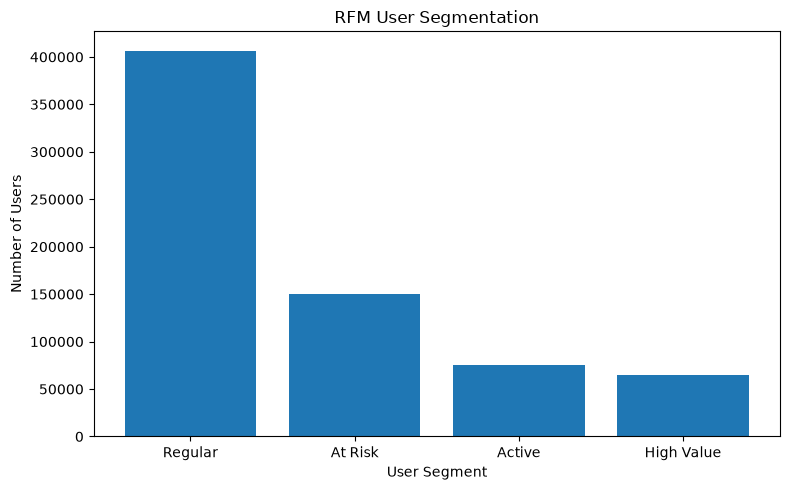

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["segment"],
    segment_summary["user_count"]
)

plt.title("RFM User Segmentation")
plt.xlabel("User Segment")
plt.ylabel("Number of Users")
plt.tight_layout()

plt.show()

## 业务分析小结

基于清洗后的约 1.10 亿条用户行为数据，对平台整体经营情况、用户行为、品类、品牌和用户价值进行了分析。

结果显示，平台用户行为以浏览为主，浏览用户中约 19.83% 发生过加购，13.12% 发生过购买。不同品类的购买转化表现存在明显差异，其中智能手机品类的购买规模和转化表现较突出。品牌方面，Samsung 的购买次数最高，而 Apple 的成交金额贡献更高。

基于购买行为构建 RFM 指标后，将购买用户划分为 Regular、At Risk、Active 和 High Value 四类，其中 High Value 用户占 9.29%，为后续用户运营和个性化推荐提供参考。

In [29]:
import os

os.makedirs("../output", exist_ok=True)

print("output 文件夹已准备好")

output 文件夹已准备好


In [31]:
for name in [
    "daily_trend",
    "category_top10",
    "brand_top10",
    "segment_summary"
]:
    print(name, "→", name in globals())

daily_trend → False
category_top10 → False
brand_top10 → False
segment_summary → True


In [33]:
daily_metrics.to_csv(
    "../output/daily_metrics.csv",
    index=False
)

top_categories.to_csv(
    "../output/top_categories.csv",
    index=False
)

top_brands.to_csv(
    "../output/top_brands.csv",
    index=False
)

segment_summary.to_csv(
    "../output/rfm_segments.csv",
    index=False
)

print("业务分析结果已保存到 output 文件夹")

业务分析结果已保存到 output 文件夹
